In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

#En este archivo no se detallan los pasos ya que son similares a los demás ejemplos con iris.

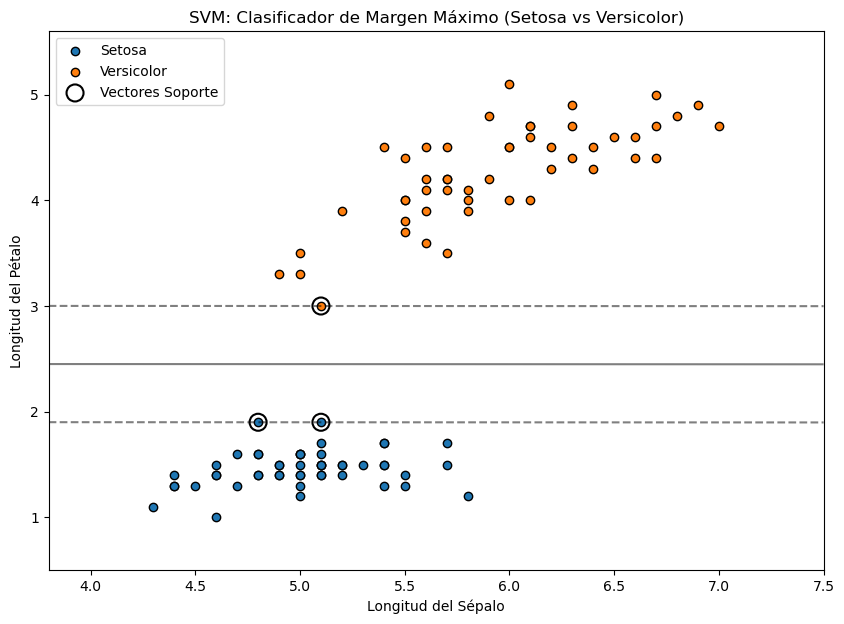

In [2]:
iris = datasets.load_iris()
X = iris.data[:, [0, 2]] 
y = iris.target
mask = (y == 0) | (y == 1) #Solo setosa y versicolor
Xv, yv= X[mask], y[mask]
modelo = SVC(kernel='linear', C=10)
modelo.fit(Xv, yv)

plt.figure(figsize=(10, 7))
ax = plt.gca()
labels=['Setosa','Versicolor']
for i, label in enumerate(np.unique(yv)):
        ax.scatter(Xv[yv==label, 0], Xv[yv==label, 1], label=labels[i], edgecolors='k')

x_min, x_max = Xv[:, 0].min() - 0.5, Xv[:, 0].max() + 0.5
y_min, y_max = Xv[:, 1].min() - 0.5, Xv[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))
Z = modelo.decision_function(np.vstack([xx.ravel(), yy.ravel()]).T).reshape(xx.shape)
ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
ax.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1], s=150,
           linewidth=1.5, facecolors='none', edgecolors='black', 
           label='Vectores Soporte')


ax.set_xlabel('Longitud del Sépalo')
ax.set_ylabel('Longitud del Pétalo')
ax.set_title('SVM: Clasificador de Margen Máximo (Setosa vs Versicolor)')

ax.legend()
plt.show()